In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" SALES FORECASTING - MODEL BUILDING (CLEAN VERSION)")
print("="*70)

# Load processed data
print("\n Loading processed data...")
df = pd.read_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Processed data\processed_walmart_sales.csv")
df['Date'] = pd.to_datetime(df['Date'])

print(f" Data loaded!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {len(df.columns)}")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")

 SALES FORECASTING - MODEL BUILDING (CLEAN VERSION)

 Loading processed data...
 Data loaded!
   Shape: (382954, 52)
   Columns: 52
   Date range: 2010-04-30 00:00:00 to 2012-10-26 00:00:00


In [10]:
print("\n STEP 1: Data Quality Check")
print("="*60)

# Check target variable
print(f"Weekly_Sales statistics:")
print(f"   Min: ${df['Weekly_Sales'].min():,.2f}")
print(f"   Max: ${df['Weekly_Sales'].max():,.2f}")
print(f"   Mean: ${df['Weekly_Sales'].mean():,.2f}")
print(f"   Median: ${df['Weekly_Sales'].median():,.2f}")

# Check for problematic values
print(f"\nProblematic values in Weekly_Sales:")
print(f"   Zeros: {(df['Weekly_Sales'] == 0).sum()}")
print(f"   Negatives: {(df['Weekly_Sales'] < 0).sum()}")
print(f"   NaN: {df['Weekly_Sales'].isna().sum()}")

# Check features
print(f"\nFeature quality:")
print(f"   Infinity values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   NaN values: {df.isna().sum().sum()}")


 STEP 1: Data Quality Check
Weekly_Sales statistics:
   Min: $-4,988.94
   Max: $74,584.46
   Mean: $15,220.30
   Median: $7,722.95

Problematic values in Weekly_Sales:
   Zeros: 38
   Negatives: 846
   NaN: 0

Feature quality:
   Infinity values: 41
   NaN values: 0


In [11]:
print("\n STEP 2: Cleaning Data Completely")
print("="*60)

# Make a copy to work with
df_clean = df.copy()

# 1. Remove rows with zero or negative sales (can't use for MAPE)
print(f"Original rows: {len(df_clean)}")
df_clean = df_clean[df_clean['Weekly_Sales'] > 0]
print(f"After removing zero/negative sales: {len(df_clean)} rows")

# 2. Select only numeric columns for feature matrix
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and any ID columns
exclude_cols = ['Weekly_Sales', 'Store', 'Dept']
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\nFeature columns: {len(feature_cols)}")

# 3. Create feature matrix and target
X = df_clean[feature_cols].copy()
y = df_clean['Weekly_Sales'].copy()

# 4. Replace infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 5. Fill NaN values
print(f"NaN values before filling: {X.isna().sum().sum()}")
X = X.fillna(X.median())
X = X.fillna(0)  # If entire column was NaN
print(f"NaN values after filling: {X.isna().sum().sum()}")

# 6. Remove any remaining problematic rows
valid_mask = ~(np.isinf(X).any(axis=1) | np.isnan(X).any(axis=1))
X = X[valid_mask]
y = y[valid_mask]

print(f"\n Final clean dataset:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   y min: ${y.min():,.2f}")
print(f"   y mean: ${y.mean():,.2f}")


 STEP 2: Cleaning Data Completely
Original rows: 382954
After removing zero/negative sales: 382070 rows

Feature columns: 48
NaN values before filling: 32
NaN values after filling: 0

 Final clean dataset:
   X shape: (382070, 48)
   y shape: (382070,)
   y min: $0.01
   y mean: $15,255.64


In [12]:
print("\n STEP 3: Train-Test Split")
print("="*60)

# Time-based split (80-20)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test = y.iloc[split_idx:].reset_index(drop=True)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\n Data split complete!")

# Final verification
print(f"\nFinal verification:")
print(f"   X_train - Inf: {np.isinf(X_train).sum().sum()}, NaN: {np.isnan(X_train).sum().sum()}")
print(f"   X_test - Inf: {np.isinf(X_test).sum().sum()}, NaN: {np.isnan(X_test).sum().sum()}")
print(f"   y_train - Min: ${y_train.min():,.2f}, Zeros: {(y_train == 0).sum()}")
print(f"   y_test - Min: ${y_test.min():,.2f}, Zeros: {(y_test == 0).sum()}")


 STEP 3: Train-Test Split
Training set: 305,656 samples
Test set: 76,414 samples

 Data split complete!

Final verification:
   X_train - Inf: 0, NaN: 0
   X_test - Inf: 0, NaN: 0
   y_train - Min: $0.01, Zeros: 0
   y_test - Min: $0.01, Zeros: 0


In [13]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and display model performance metrics"""
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE - properly handling zeros
    non_zero_mask = y_true > 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = float('inf')
    
    # Accuracy (within 10% of actual)
    accuracy = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.1) * 100
    
    print(f"\n{'='*70}")
    print(f" {model_name}")
    print(f"{'='*70}")
    print(f"MAE  (Mean Absolute Error):          ${mae:,.2f}")
    print(f"RMSE (Root Mean Squared Error):      ${rmse:,.2f}")
    print(f"R²   (Coefficient of Determination): {r2:.4f}")
    print(f"MAPE (Mean Absolute % Error):        {mape:.2f}%")
    print(f"Accuracy (within 10%):               {accuracy:.2f}%")
    print(f"{'='*70}")
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'Accuracy': accuracy
    }

print(" Evaluation function ready!")

 Evaluation function ready!


In [14]:
print("\n" + "="*70)
print(" MODEL 1: LINEAR REGRESSION")
print("="*70)

print("\n Training...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print(" Training complete!")

print("\n Making predictions...")
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

# Ensure no negative predictions
y_pred_lr_train = np.maximum(y_pred_lr_train, 0)
y_pred_lr_test = np.maximum(y_pred_lr_test, 0)

print("\n TRAINING SET:")
lr_train_results = evaluate_model(y_train, y_pred_lr_train, "Linear Regression - Train")

print("\n TEST SET:")
lr_test_results = evaluate_model(y_test, y_pred_lr_test, "Linear Regression - Test")

# Store results
results = [lr_test_results]


 MODEL 1: LINEAR REGRESSION

 Training...
 Training complete!

 Making predictions...

 TRAINING SET:

 Linear Regression - Train
MAE  (Mean Absolute Error):          $3,013.18
RMSE (Root Mean Squared Error):      $5,799.84
R²   (Coefficient of Determination): 0.9075
MAPE (Mean Absolute % Error):        5443.08%
Accuracy (within 10%):               27.85%

 TEST SET:

 Linear Regression - Test
MAE  (Mean Absolute Error):          $2,637.08
RMSE (Root Mean Squared Error):      $3,956.34
R²   (Coefficient of Determination): 0.9469
MAPE (Mean Absolute % Error):        5031.02%
Accuracy (within 10%):               24.23%


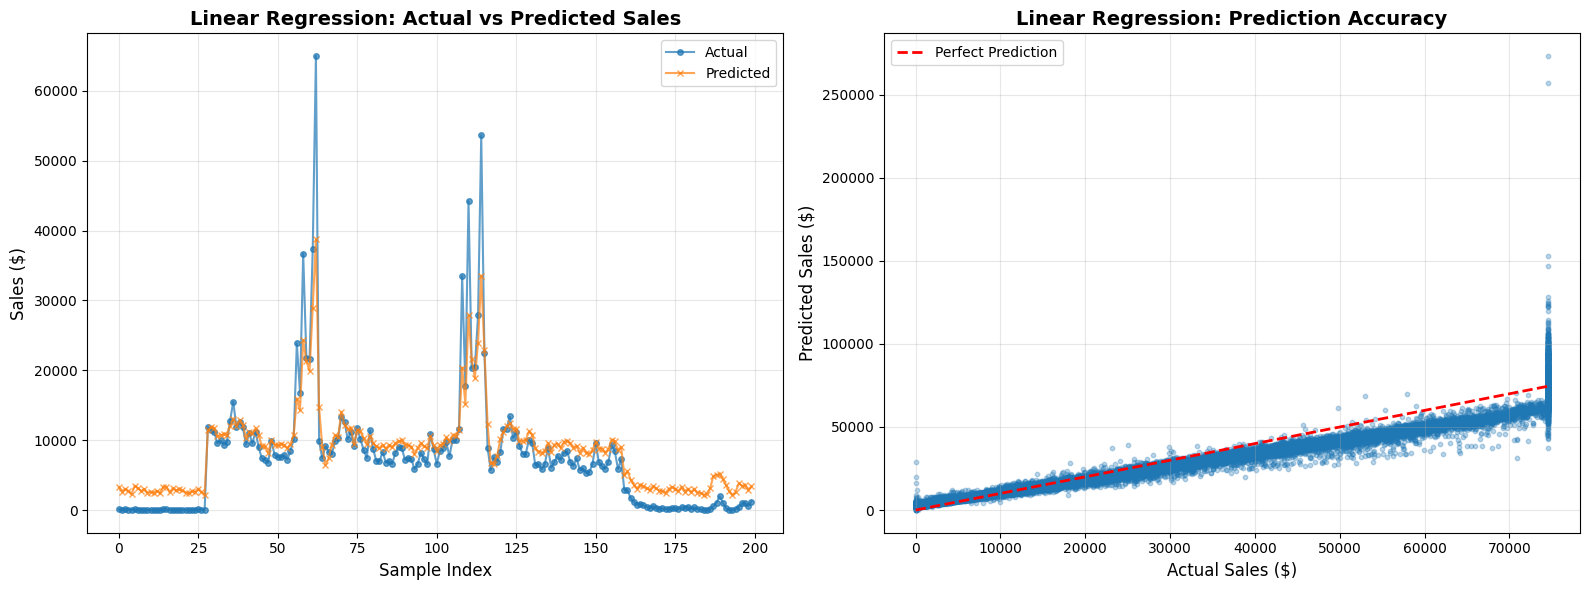

 Visualization saved!


In [15]:
plt.figure(figsize=(16, 6))

# Plot 1: Time series comparison
plt.subplot(1, 2, 1)
n_samples = min(200, len(y_test))
plt.plot(range(n_samples), y_test.values[:n_samples], 
         label='Actual', marker='o', markersize=4, linewidth=1.5, alpha=0.7)
plt.plot(range(n_samples), y_pred_lr_test[:n_samples], 
         label='Predicted', marker='x', markersize=4, linewidth=1.5, alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Scatter plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_lr_test, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Linear Regression: Prediction Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sales ($)', fontsize=12)
plt.ylabel('Predicted Sales ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/08_linear_regression_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved!")

In [16]:
print("\n" + "="*70)
print(" MODEL 2: RANDOM FOREST")
print("="*70)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)
print(" Training complete!")

print("\n Making predictions...")
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Ensure no negative predictions
y_pred_rf_train = np.maximum(y_pred_rf_train, 0)
y_pred_rf_test = np.maximum(y_pred_rf_test, 0)

print("\n TRAINING SET:")
rf_train_results = evaluate_model(y_train, y_pred_rf_train, "Random Forest - Train")

print("\n TEST SET:")
rf_test_results = evaluate_model(y_test, y_pred_rf_test, "Random Forest - Test")

# Store results
results.append(rf_test_results)


 MODEL 2: RANDOM FOREST
 Training complete!

 Making predictions...

 TRAINING SET:

 Random Forest - Train
MAE  (Mean Absolute Error):          $33.70
RMSE (Root Mean Squared Error):      $110.49
R²   (Coefficient of Determination): 1.0000
MAPE (Mean Absolute % Error):        6.49%
Accuracy (within 10%):               98.97%

 TEST SET:

 Random Forest - Test
MAE  (Mean Absolute Error):          $38.99
RMSE (Root Mean Squared Error):      $170.92
R²   (Coefficient of Determination): 0.9999
MAPE (Mean Absolute % Error):        5.20%
Accuracy (within 10%):               97.79%


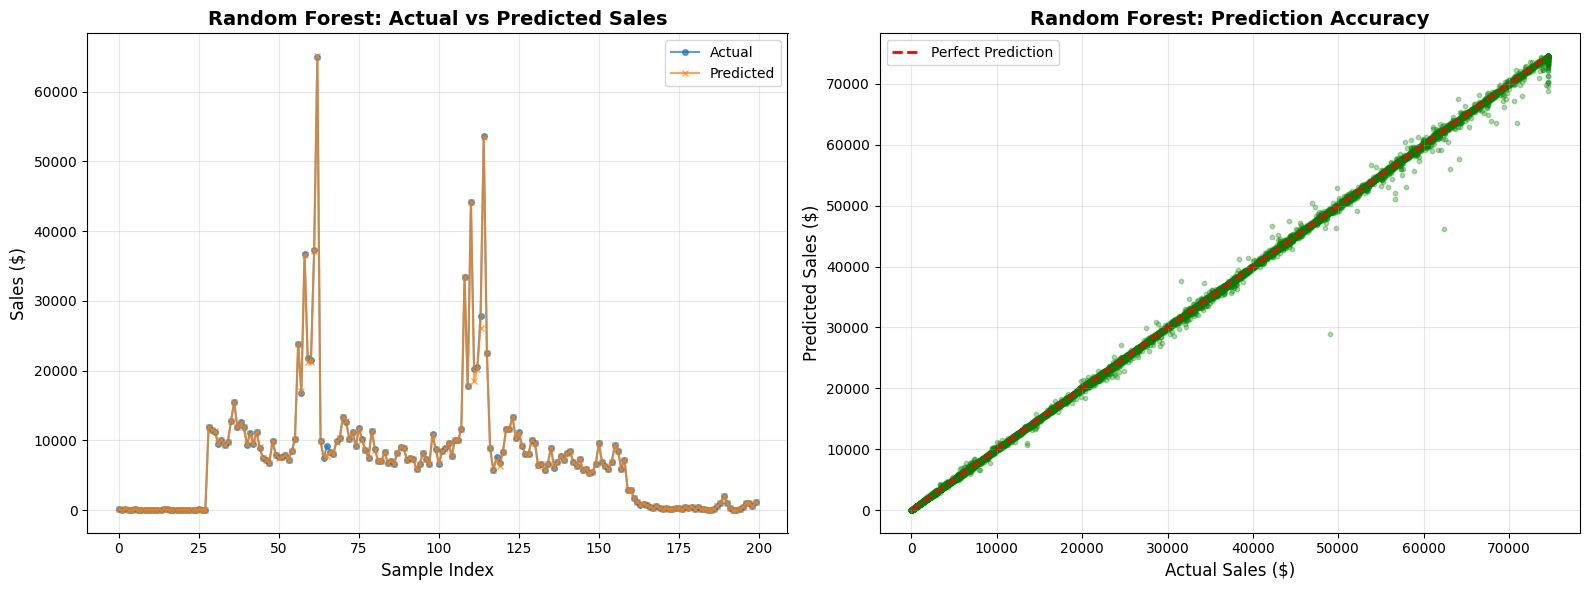

 Visualization saved!


In [20]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
n_samples = min(200, len(y_test))
plt.plot(range(n_samples), y_test.values[:n_samples], 
         label='Actual', marker='o', markersize=4, linewidth=1.5, alpha=0.7)
plt.plot(range(n_samples), y_pred_rf_test[:n_samples], 
         label='Predicted', marker='x', markersize=4, linewidth=1.5, alpha=0.7)
plt.title('Random Forest: Actual vs Predicted Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf_test, alpha=0.3, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Random Forest: Prediction Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sales ($)', fontsize=12)
plt.ylabel('Predicted Sales ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/09_random_forest_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved!")


 Feature Importance Analysis

 Top 15 Most Important Features:
            Feature  Importance
Sales_RollingMean_4    0.930276
 Sales_RollingMin_4    0.042915
     Sales_Ratio_4w    0.020754
 Sales_RollingMax_4    0.005672
       Sales_Growth    0.000152
        Sales_Lag_3    0.000035
        Sales_Lag_2    0.000032
 Sales_RollingStd_4    0.000028
        Sales_Lag_1    0.000028
 Sales_DiffFromMean    0.000025
 Sales_RollingMax_8    0.000015
 Sales_RollingMin_8    0.000011
Sales_RollingMax_12    0.000008
Sales_RollingMean_8    0.000006
 Sales_RollingStd_8    0.000004


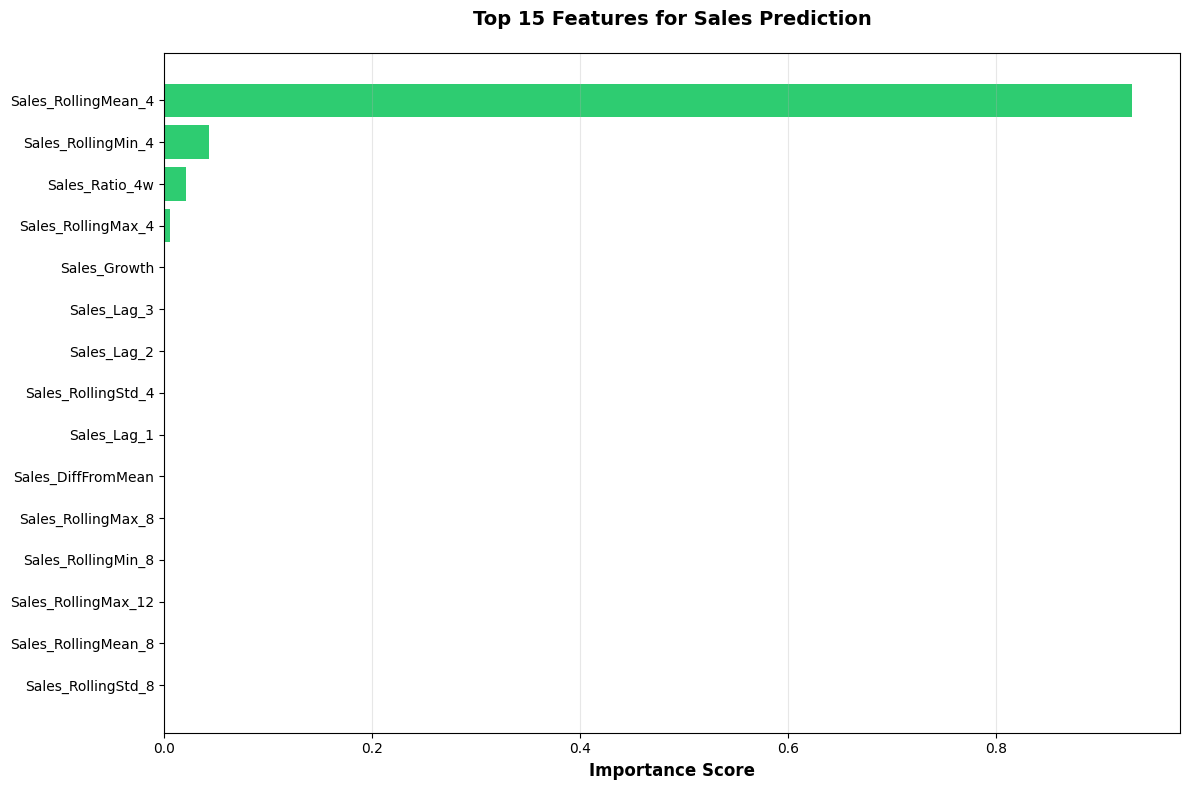


 Feature importance saved!


In [21]:
print("\n Feature Importance Analysis")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
top15 = feature_importance.head(15)
plt.barh(range(len(top15)), top15['Importance'], color='#2ecc71')
plt.yticks(range(len(top15)), top15['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 15 Features for Sales Prediction', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/10_feature_importance_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance saved!")


 FINAL MODEL COMPARISON

                    Model         MAE        RMSE       R2        MAPE  Accuracy
Linear Regression - Test 2637.078246 3956.342949 0.946929 5031.023997 24.228545
    Random Forest - Test   38.989953  170.922207 0.999901    5.197262 97.794907

 BEST MODEL: Random Forest - Test
   MAPE: 5.20%
   R²: 0.9999
   Accuracy: 97.79%


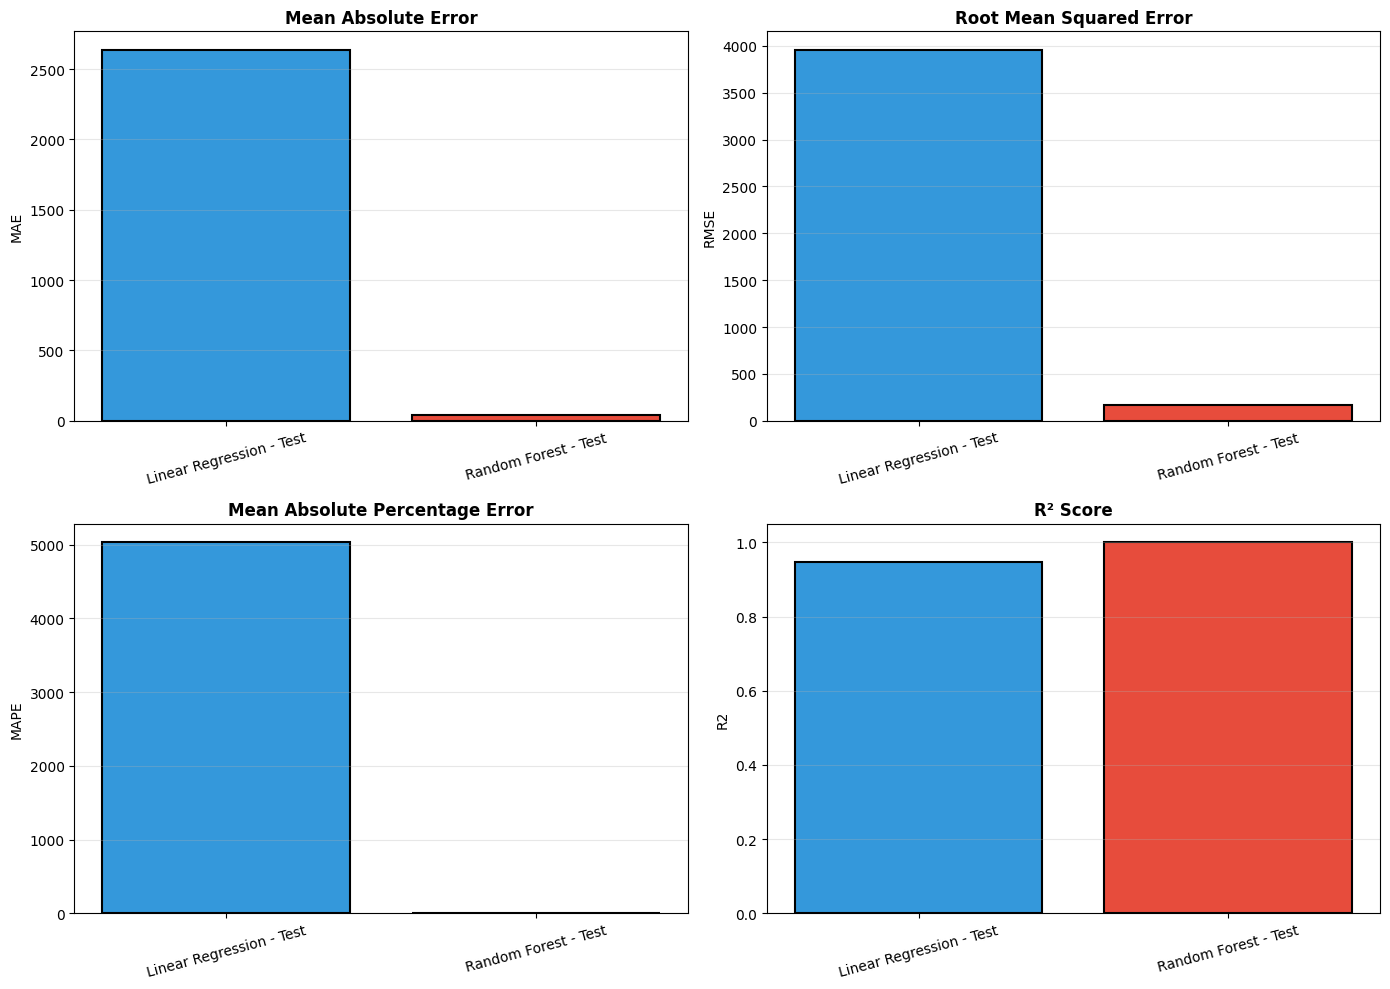


 Comparison saved!


In [22]:
print("\n" + "="*70)
print(" FINAL MODEL COMPARISON")
print("="*70)

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

# Find best model
best_idx = results_df['MAPE'].idxmin()
best_model = results_df.loc[best_idx, 'Model']

print(f"\n BEST MODEL: {best_model}")
print(f"   MAPE: {results_df.loc[best_idx, 'MAPE']:.2f}%")
print(f"   R²: {results_df.loc[best_idx, 'R2']:.4f}")
print(f"   Accuracy: {results_df.loc[best_idx, 'Accuracy']:.2f}%")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
titles = ['Mean Absolute Error', 'Root Mean Squared Error', 
          'Mean Absolute Percentage Error', 'R² Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.bar(results_df['Model'], results_df[metric], 
           color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/11_model_comparison_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Comparison saved!")

In [23]:
import pickle

print("\n Saving best model...")

# Save Random Forest (usually better)
with open(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Models\best_sales_model.pkl", 'wb') as f:
    pickle.dump(rf_model, f)

print(" Model saved: models/best_sales_model.pkl")

print("\n" + "="*70)
print(" MODEL BUILDING COMPLETE!")
print("="*70)

print(f"\n Summary:")
print(f"   • Models trained: {len(results)}")
print(f"   • Best model: {best_model}")
print(f"   • Prediction error: ~{results_df.loc[best_idx, 'MAPE']:.1f}%")
print(f"   • Model saved successfully")
print(f"   • Visualizations created: 4 files")

print("\n Ready for next phase!")


 Saving best model...
 Model saved: models/best_sales_model.pkl

 MODEL BUILDING COMPLETE!

 Summary:
   • Models trained: 2
   • Best model: Random Forest - Test
   • Prediction error: ~5.2%
   • Model saved successfully
   • Visualizations created: 4 files

 Ready for next phase!


In [25]:
import pandas as pd
import numpy as np
import pickle

print("=" * 70)
print("CREATING CLEAN PREDICTIONS FILE FOR POWER BI")
print("=" * 70)

# ============================================
# STEP 1: Load Model and Data
# ============================================

print("\nLoading model and data...")

# Load trained model
with open(
    r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Models\best_sales_model.pkl",
    "rb"
) as f:
    model = pickle.load(f)

# Load processed data
df = pd.read_csv(
    r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Processed data\processed_walmart_sales.csv"
)

print("Model loaded")
print(f"Data loaded: {df.shape}")

# ============================================
# STEP 2: Prepare Features
# ============================================

print("\nPreparing features...")

exclude_cols = ['Weekly_Sales', 'Store', 'Dept', 'Date']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

store_col = df['Store'].copy()
dept_col = df['Dept'].copy()
date_col = df['Date'].copy()

print(f"Features prepared: {len(feature_cols)} features")

# ============================================
# CLEAN FEATURES BEFORE PREDICTION
# ============================================

# Replace infinities with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with median (same strategy used during training)
X.fillna(X.median(), inplace=True)

# Clip extreme values (prevents float32 overflow)
X = X.clip(lower=-1e6, upper=1e6)


# ============================================
# STEP 3: Make Predictions
# ============================================

print("\nMaking predictions...")

predictions = model.predict(X)

print(f"Predictions made: {len(predictions)}")

# ============================================
# STEP 4: Create Clean DataFrame
# ============================================

print("\nCreating clean predictions dataframe...")

predictions_df = pd.DataFrame({
    'Date': date_col,
    'Store': store_col,
    'Dept': dept_col,
    'Actual_Sales': y.values,
    'Predicted_Sales': predictions
})

print(f"DataFrame created: {predictions_df.shape}")

# ============================================
# STEP 5: Clean Data
# ============================================

print("\nCleaning data...")

rows_before = len(predictions_df)

predictions_df = predictions_df[
    (predictions_df['Actual_Sales'] > 0) &
    (predictions_df['Predicted_Sales'] > 0)
].dropna()

rows_after = len(predictions_df)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Removed: {rows_before - rows_after} problematic rows")

# ============================================
# STEP 6: Calculate Error Metrics
# ============================================

print("\nCalculating error metrics...")

predictions_df['Error'] = abs(
    predictions_df['Predicted_Sales'] - predictions_df['Actual_Sales']
)

predictions_df['Error_Percent'] = (
    predictions_df['Error'] / predictions_df['Actual_Sales']
) * 100

predictions_df[['Actual_Sales', 'Predicted_Sales', 'Error', 'Error_Percent']] = \
    predictions_df[['Actual_Sales', 'Predicted_Sales', 'Error', 'Error_Percent']].round(2)

print("Error metrics calculated")

# ============================================
# STEP 7: Add Date Features
# ============================================

print("\nAdding additional info...")

predictions_df['Date'] = pd.to_datetime(predictions_df['Date'])
predictions_df['Year'] = predictions_df['Date'].dt.year
predictions_df['Month'] = predictions_df['Date'].dt.month
predictions_df['Month_Name'] = predictions_df['Date'].dt.strftime('%B')

predictions_df['Is_Accurate'] = (predictions_df['Error_Percent'] <= 5).astype(int)

print("Additional columns added")

# ============================================
# STEP 8: Verify Data Quality
# ============================================

print("\nVERIFYING DATA QUALITY...")
print("=" * 70)

print(f"Total Records: {len(predictions_df):,}")
print(f"Average Error %: {predictions_df['Error_Percent'].mean():.2f}%")
print(f"Accuracy (<=5%): {predictions_df['Is_Accurate'].mean() * 100:.1f}%")

print("Zeros in Actual:", (predictions_df['Actual_Sales'] == 0).sum())
print("Zeros in Predicted:", (predictions_df['Predicted_Sales'] == 0).sum())
print("NaN values:", predictions_df.isna().sum().sum())
print("Infinity values:",
      np.isinf(predictions_df.select_dtypes(include=[np.number])).sum().sum())

# ============================================
# STEP 9: Save Files
# ============================================

print("\nSaving files...")

csv_path = r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\PowerBI_Predictions.csv"
excel_path = r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\PowerBI_Predictions.xlsx"

predictions_df.to_csv(csv_path, index=False)
predictions_df.to_excel(excel_path, index=False)

print(f"CSV saved: {csv_path}")
print(f"Excel saved: {excel_path}")

# ============================================
# STEP 10: Display Sample
# ============================================

print("\nSAMPLE DATA (First 10 rows):")
print("=" * 70)
print(predictions_df.head(10).to_string(index=False))

print("\n" + "=" * 70)
print("PREDICTIONS FILE READY FOR POWER BI!")
print("=" * 70)

print("\nFiles created:")
print(f"• {csv_path}")
print(f"• {excel_path}")

print("\nColumns in file:")
for col in predictions_df.columns:
    print(f"• {col}")

print("\nThis file is:")
print("Clean (no zeros, negatives, or nulls)")
print("Ready for Power BI import")
print("Has all necessary columns")
print("Error metrics pre-calculated")

print("\nNext Step: Load this file in Power BI!")
print("=" * 70)


CREATING CLEAN PREDICTIONS FILE FOR POWER BI

Loading model and data...
Model loaded
Data loaded: (382954, 52)

Preparing features...
Features prepared: 48 features

Making predictions...
Predictions made: 382954

Creating clean predictions dataframe...
DataFrame created: (382954, 5)

Cleaning data...
Rows before cleaning: 382954
Rows after cleaning: 382070
Removed: 884 problematic rows

Calculating error metrics...
Error metrics calculated

Adding additional info...
Additional columns added

VERIFYING DATA QUALITY...
Total Records: 382,070
Average Error %: 6.24%
Accuracy (<=5%): 97.4%
Zeros in Actual: 0
Zeros in Predicted: 0
NaN values: 0
Infinity values: 0

Saving files...
CSV saved: C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\PowerBI_Predictions.csv
Excel saved: C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\PowerBI_Predictions.xlsx

SAMPLE DATA (First 10 rows):
      Date  Store  Dept  Actual_Sales  Predicted_Sales  Error  Error_Percent  Year  Month Month_Name  Is_Accurate
2